In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_bondgraph)=
# Get bondgraph

*Extracting the covalent bond graph of a molecular system.*

The function {func}`molsysmt.topology.get_bondgraph` extracts the network graph of covalent bonds where atoms represent nodes and covalent bonds represent edges.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.topology.get_bondgraph`.
:::


## Basic usage

Let's show how to extract a network graph representation of covalent bonds for Met-enkephalin:


In [2]:
import molsysmt as msm
import networkx as nx
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['Met-enkephalin']['met_enkephalin.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We extract the bond graph as a NetworkX graph using {func}`molsysmt.topology.get_bondgraph`:


In [4]:
graph = msm.topology.get_bondgraph(molsys, to_form='networkx.Graph')


In [5]:
n_nodes = graph.number_of_nodes()
n_edges = graph.number_of_edges()
print(f'The graph has {n_nodes} nodes and {n_edges} edges.')


The graph has 72 nodes and 73 edges.


## Visualizing the 2D bond graph

We can render the 2D topology graph using NetworkX and Matplotlib, labeling nodes with their atom names:


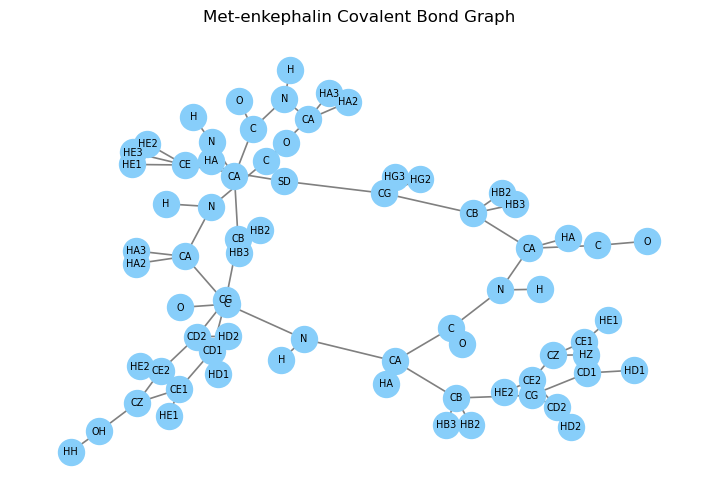

In [6]:
atom_names = msm.get(molsys, element='atom', name=True)
labels = {i: atom_names[i] for i in range(len(atom_names))}

plt.figure(figsize=(9, 6))
pos = nx.spring_layout(graph, seed=42)
nx.draw_networkx_nodes(graph, pos, node_color='lightskyblue', node_size=350)
nx.draw_networkx_edges(graph, pos, edge_color='gray', width=1.2)
nx.draw_networkx_labels(graph, pos, labels=labels, font_size=7)
plt.title('Met-enkephalin Covalent Bond Graph')
plt.axis('off')
plt.show()


## Connected components analysis

We can compute the number of connected covalent components using NetworkX functions:


In [7]:
components = list(nx.connected_components(graph))
print(f'Number of connected covalent components: {len(components)}')


Number of connected covalent components: 1


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query atom and bond properties with {func}`molsysmt.basic.get`.
- {ref}`Get covalent blocks <Tutorial_Get_covalent_blocks>`: Partition molecular systems into disconnected covalent blocks with {func}`molsysmt.topology.get_covalent_blocks`.
- {ref}`Get covalent paths <Tutorial_Get_covalent_paths>`: Search for covalent bond chains matching sequence patterns with {func}`molsysmt.topology.get_covalent_paths`.
:::
